In [12]:
import pickle 
import matplotlib.pyplot as plt
import math 
import numpy as np

## Env

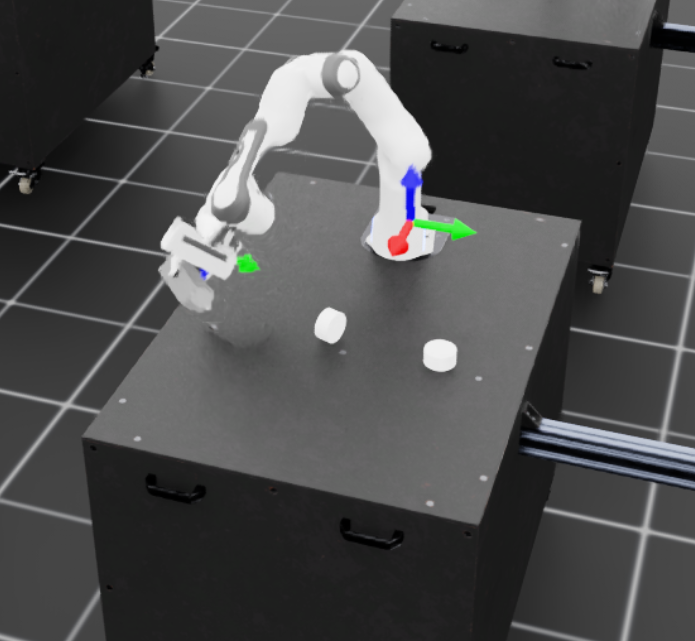

### 0.Scene 

* robot - Franka-Panda

* Tetra pack spawn with random yaw 

* Tin can spawn with straight and flat spawn positions 

Randomization of position and orientation of objects

### 1. Observations 

* Joint position - robot angles from motor encoders 

* Joint velocities - robot motor angular velocities 

* Object position - position of object in gripper frame  

* Object orientation - yaw angle of object  

* Previous action - last robot action, robot joint poositions + gripper action 

* class type - one hot encoded vector of object class 

### 2. Rewards 

* reaching_object - minimize l2 distance between object and gripper frame

* lifting_object - reward for object height counting from table surface 

* object_panelty_xy - penalty for object moving along xy axis 

* ori_gripper - cosinus distance reward for z-axis of gripper being co-directional with negative z-axis of table (gripper look straight down) 

* regi - make gripper far way from robot base link, to prevent lifting object without grasp 

* action_rate - penalty for big difference between adjacent actions 

* joint_vel - penlty for big angular velocities of motors

### 3. Actions  

* robot joint positions - only arm

* gripper actions - converting to binary command close/open (action by policy < 0 or not)

### 4. Terminations  

* Object xy distance from spawn position too far 

* time out - episode length termination

### 5. Policy/Critic architecture, Algorithm

I choose PPO algorithm, becuase i think it is most suitable for continous control problems  

Policy is MLP [256, 128, 64] 

Critic is MLP [256, 128, 64] 

Entropy regularization coeff - 0.004

## Training plots

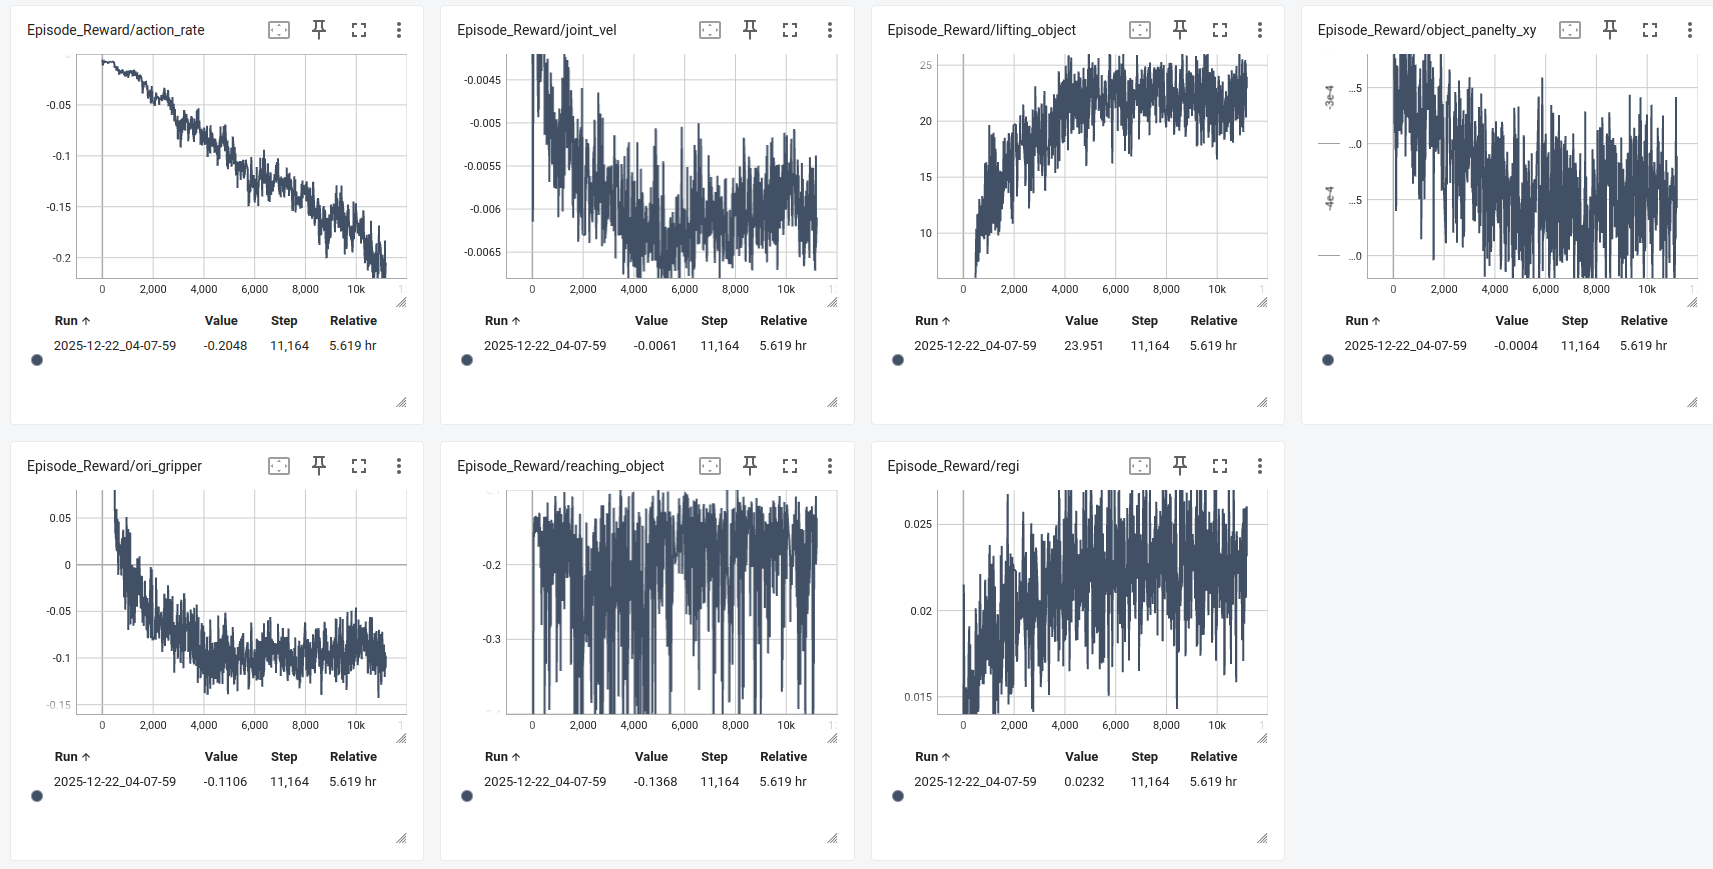

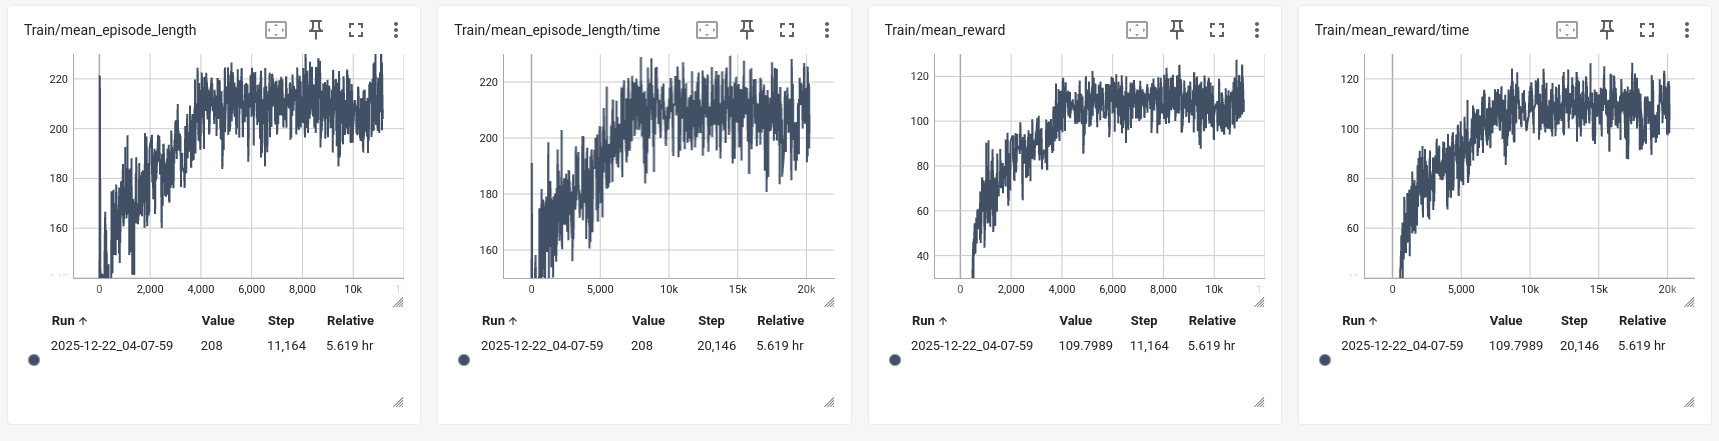

## Evaluation

### 6. Success Rate evaluation

In [3]:
with open('data.pkl', 'rb') as data_file:
    data_dict = pickle.load(data_file)

In [4]:
tetra_yaw_angle, tetra_success = list(data_dict[0].keys()), list(data_dict[0].values()) 
tetra_yaw_angle = [yaw if yaw < math.pi else yaw - 2 * math.pi for yaw in tetra_yaw_angle]

In [5]:
can_yaw_angle, can_success = list(data_dict[1].keys()), list(data_dict[1].values()) 
can_yaw_angle = [yaw if yaw < math.pi else yaw - 2 * math.pi for yaw in can_yaw_angle]

In [6]:
can_flat_yaw_angle, can_flat_success = list(data_dict[2].keys()), list(data_dict[2].values()) 
can_flat_yaw_angle = [yaw if yaw < math.pi else yaw - 2 * math.pi for yaw in can_flat_yaw_angle]

In [7]:
def smoothed_success_rate(yaw_angle):
    interval = 0.1
    step = interval / 2
    cur_rad = min(yaw_angle) + step - 0.0001
    success_rate_interval = [] 
    average_rad = []
    while cur_rad < max(yaw_angle) - step + 0.0001: 
        cur_sum = 0
        cur_n = 0
        for j in range(len(yaw_angle)):
            if yaw_angle[j] > cur_rad - step and yaw_angle[j] < cur_rad + step:
                cur_sum += tetra_success[j]
                cur_n += 1
        
        if cur_n != 0:
            success_rate_interval.append(cur_sum / cur_n)
            average_rad.append(cur_rad)
        cur_rad += step

    return average_rad, success_rate_interval

In [ ]:
tetra_average_rad, tetra_smoothed_success_rate = smoothed_success_rate(tetra_yaw_angle) 
can_average_rad, can_smoothed_success_rate = smoothed_success_rate(can_yaw_angle)  
# can_flat_average_rad, can_flat_smoothed_success_rate = smoothed_success_rate(can_flat_yaw_angle)

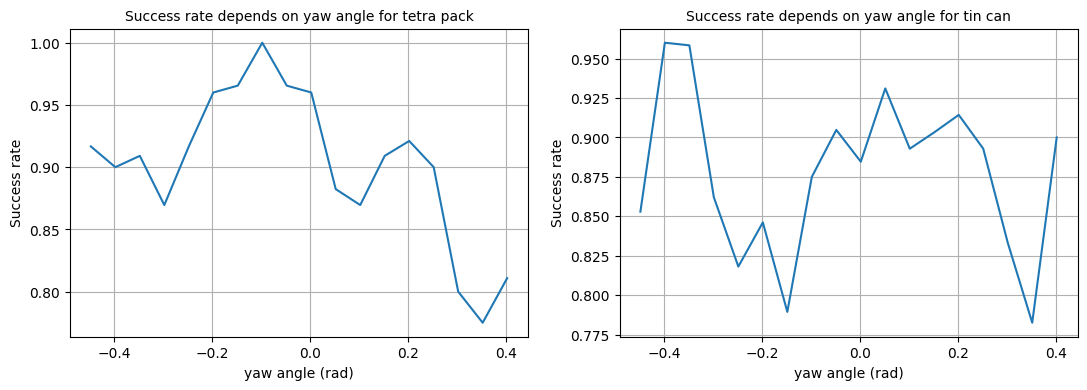

In [10]:
fig, ax = plt.subplots(1, 2, figsize = (13, 4))  
ax[0].set_title('Success rate depends on yaw angle for tetra pack', fontsize=10) 
ax[1].set_title('Success rate depends on yaw angle for tin can', fontsize=10)  
ax[0].grid() 
ax[1].grid() 
ax[0].set_xlabel('yaw angle (rad)', fontsize=10) 
ax[0].set_ylabel('Success rate', fontsize=10) 
ax[1].set_xlabel('yaw angle (rad)', fontsize=10) 
ax[1].set_ylabel('Success rate', fontsize=10) 
ax[0].plot(tetra_average_rad, tetra_smoothed_success_rate)
ax[1].plot(can_average_rad, can_smoothed_success_rate)  

In [ ]:
print(f'tetra pack overall success rate: {np.array(tetra_smoothed_success_rate).mean()}')
print(f'tin can overall success rate: {np.array(can_smoothed_success_rate).mean()}') 
print(f'tin can flat overall success rate: {np.array(can_flat_success).mean()}')

tetra pack overall success rate: 0.9017164695901452
tin can overall success rate: 0.8778740239689102
tin can flat success rate: 0.9236641221374046


### 7. Gripper Orientation evaluation

In [16]:
with open('ori.pkl', 'rb') as ori_file:
    ori_dict = pickle.load(ori_file)

In [22]:
robot_roll_tetra, robot_pitch_tetra, robot_yaw_tetra = ori_dict[0]['roll'], ori_dict[0]['pitch'], ori_dict[0]['yaw'] 
robot_roll_can, robot_pitch_can, robot_yaw_can = ori_dict[1]['roll'], ori_dict[1]['pitch'], ori_dict[1]['yaw'] 
robot_roll_flat_can, robot_pitch_flat_can, robot_yaw_flat_can = ori_dict[2]['roll'], ori_dict[2]['pitch'], ori_dict[2]['yaw'] 

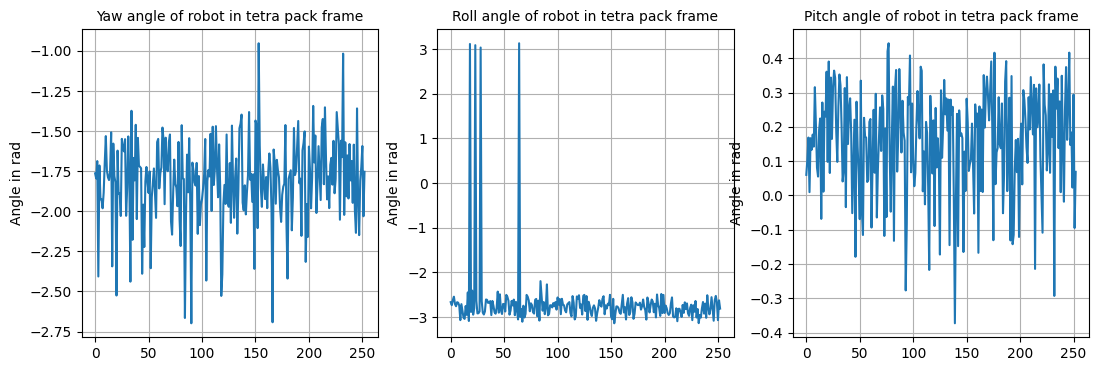

In [18]:
fig, ax = plt.subplots(1, 3, figsize = (13, 4))  
ax[0].set_title('Yaw angle of robot in tetra pack frame', fontsize=10)
ax[1].set_title('Roll angle of robot in tetra pack frame', fontsize=10) 
ax[2].set_title('Pitch angle of robot in tetra pack frame', fontsize=10)
ax[0].grid() 
ax[1].grid()
ax[2].grid()
ax[0].set_ylabel('Angle in rad', fontsize=10) 
ax[1].set_ylabel('Angle in rad', fontsize=10) 
ax[2].set_ylabel('Angle in rad', fontsize=10) 
ax[0].plot(robot_yaw_tetra)
ax[1].plot(robot_roll_tetra) 
ax[2].plot(robot_pitch_tetra) 

In [19]:
import numpy as np 

# convert to numpy 
np_robot_yaw_tetra = np.array(robot_yaw_tetra) 
np_robot_roll_tetra = np.array(robot_roll_tetra) 
np_robot_pitch_tetra = np.array(robot_pitch_tetra)

robot_yaw_tetra_mean, robot_yaw_tetra_std = np_robot_yaw_tetra.mean(), np_robot_yaw_tetra.std()
robot_roll_tetra_mean, robot_roll_tetra_std = np_robot_roll_tetra.mean(), np_robot_roll_tetra.std()
robot_pitch_tetra_mean, robot_pitch_tetra_std = np_robot_pitch_tetra.mean(), np_robot_pitch_tetra.std() 


print(f'robot yaw in tetra pack frame mean: {robot_yaw_tetra_mean}; std: {robot_yaw_tetra_std}')
print(f'robot roll in tetra pack frame mean: {robot_roll_tetra_mean}; std: {robot_roll_tetra_std}')
print(f'robot pitch in tetra pack frame mean: {robot_pitch_tetra_mean}; std: {robot_pitch_tetra_std}')

print(f'robot yaw interval: ({robot_yaw_tetra_mean -robot_yaw_tetra_std}, {robot_yaw_tetra_mean + robot_yaw_tetra_std})')
print(f'robot roll interval: ({robot_roll_tetra_mean -robot_roll_tetra_std}, {robot_roll_tetra_mean + robot_roll_tetra_std})')
print(f'robot pitch interval: ({robot_pitch_tetra_mean -robot_pitch_tetra_std}, {robot_pitch_tetra_mean + robot_pitch_tetra_std})')

robot yaw in tetra pack frame mean: -1.8091351505324775; std: 0.2618640758688504
robot roll in tetra pack frame mean: -2.6882976317122993; std: 0.7519551146629155
robot pitch in tetra pack frame mean: 0.15749122598760654; std: 0.1544810932210519
robot yaw interval: (-2.070999226401328, -1.5472710746636271)
robot roll interval: (-3.440252746375215, -1.9363425170493838)
robot pitch interval: (0.003010132766554624, 0.3119723192086584)


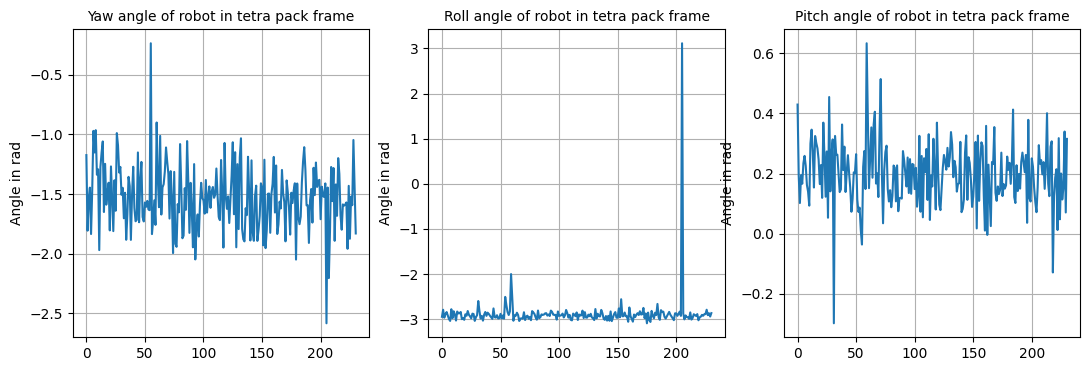

In [20]:
fig, ax = plt.subplots(1, 3, figsize = (13, 4))  
ax[0].set_title('Yaw angle of robot in tetra pack frame', fontsize=10)
ax[1].set_title('Roll angle of robot in tetra pack frame', fontsize=10) 
ax[2].set_title('Pitch angle of robot in tetra pack frame', fontsize=10)
ax[0].grid() 
ax[1].grid()
ax[2].grid()
ax[0].set_ylabel('Angle in rad', fontsize=10) 
ax[1].set_ylabel('Angle in rad', fontsize=10) 
ax[2].set_ylabel('Angle in rad', fontsize=10) 
ax[0].plot(robot_yaw_can)
ax[1].plot(robot_roll_can) 
ax[2].plot(robot_pitch_can) 

In [24]:
# convert to numpy 
np_robot_yaw_can = np.array(robot_yaw_can) 
np_robot_roll_can = np.array(robot_roll_can) 
np_robot_pitch_can = np.array(robot_pitch_can)

robot_yaw_can_mean, robot_yaw_can_std = np_robot_yaw_can.mean(), np_robot_yaw_can.std()
robot_roll_can_mean, robot_roll_can_std = np_robot_roll_can.mean(), np_robot_roll_can.std()
robot_pitch_can_mean, robot_pitch_can_std = np_robot_pitch_can.mean(), np_robot_pitch_can.std() 


print(f'robot yaw in tetra pack frame mean: {robot_yaw_can_mean}; std: {robot_yaw_can_std}')
print(f'robot roll in tetra pack frame mean: {robot_roll_can_mean}; std: {robot_roll_can_std}')
print(f'robot pitch in tetra pack frame mean: {robot_pitch_can_mean}; std: {robot_pitch_can_std}') 

print(f'robot yaw interval: ({robot_yaw_can_mean -robot_yaw_can_std}, {robot_yaw_can_mean + robot_yaw_can_std})')
print(f'robot roll interval: ({robot_roll_can_mean -robot_roll_can_std}, {robot_roll_can_mean + robot_roll_can_std})')
print(f'robot pitch interval: ({robot_pitch_can_mean -robot_pitch_can_std}, {robot_pitch_can_mean + robot_pitch_can_std})')

robot yaw in tetra pack frame mean: -1.5305977218594902; std: 0.27256831134713855
robot roll in tetra pack frame mean: -2.883940614147104; std: 0.40919790337198847
robot pitch in tetra pack frame mean: 0.19936792511750998; std: 0.10585500466104698
robot yaw interval: (-1.8031660332066286, -1.2580294105123517)
robot roll interval: (-3.2931385175190924, -2.474742710775115)
robot pitch interval: (0.09351292045646299, 0.305222929778557)


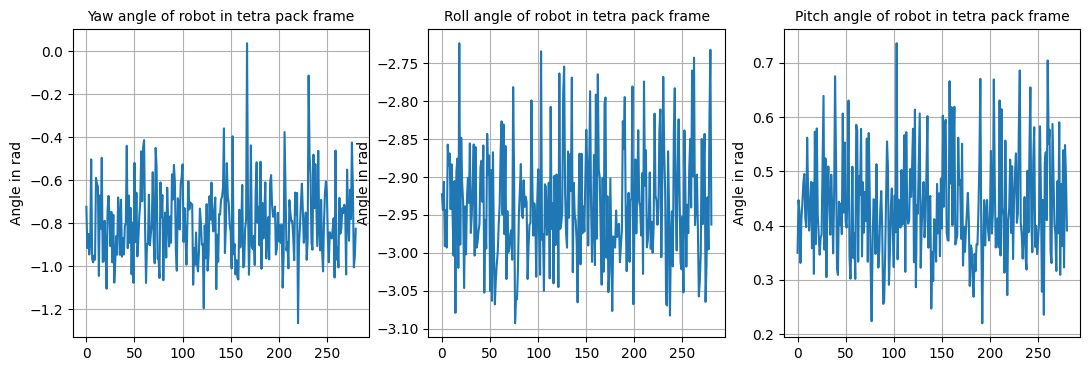

In [25]:
fig, ax = plt.subplots(1, 3, figsize = (13, 4))  
ax[0].set_title('Yaw angle of robot in tetra pack frame', fontsize=10)
ax[1].set_title('Roll angle of robot in tetra pack frame', fontsize=10) 
ax[2].set_title('Pitch angle of robot in tetra pack frame', fontsize=10)
ax[0].grid() 
ax[1].grid()
ax[2].grid()
ax[0].set_ylabel('Angle in rad', fontsize=10) 
ax[1].set_ylabel('Angle in rad', fontsize=10) 
ax[2].set_ylabel('Angle in rad', fontsize=10) 
ax[0].plot(robot_yaw_flat_can)
ax[1].plot(robot_roll_flat_can) 
ax[2].plot(robot_pitch_flat_can) 

In [26]:
np_robot_yaw_flat_can = np.array(robot_yaw_flat_can) 
np_robot_roll_flat_can = np.array(robot_roll_flat_can) 
np_robot_pitch_flat_can = np.array(robot_pitch_flat_can)

robot_yaw_flat_can_mean, robot_yaw_flat_can_std = np_robot_yaw_flat_can.mean(), np_robot_yaw_flat_can.std()
robot_roll_flat_can_mean, robot_roll_flat_can_std = np_robot_roll_flat_can.mean(), np_robot_roll_flat_can.std()
robot_pitch_flat_can_mean, robot_pitch_flat_can_std = np_robot_pitch_flat_can.mean(), np_robot_pitch_flat_can.std() 


print(f'robot yaw in tetra pack frame mean: {robot_yaw_flat_can_mean}; std: {robot_yaw_flat_can_std}')
print(f'robot roll in tetra pack frame mean: {robot_roll_flat_can_mean}; std: {robot_roll_flat_can_std}')
print(f'robot pitch in tetra pack frame mean: {robot_pitch_flat_can_mean}; std: {robot_pitch_flat_can_std}') 

print(f'robot yaw interval: ({robot_yaw_flat_can_mean -robot_yaw_flat_can_std}, {robot_yaw_flat_can_mean + robot_yaw_flat_can_std})')
print(f'robot roll interval: ({robot_roll_flat_can_mean -robot_roll_flat_can_std}, {robot_roll_flat_can_mean + robot_roll_flat_can_std})')
print(f'robot pitch interval: ({robot_pitch_flat_can_mean -robot_pitch_flat_can_std}, {robot_pitch_flat_can_mean + robot_pitch_flat_can_std})')

robot yaw in tetra pack frame mean: -0.7977554470937023; std: 0.17868318027027638
robot roll in tetra pack frame mean: -2.936353044577765; std: 0.07692949011519809
robot pitch in tetra pack frame mean: 0.4344089621963026; std: 0.09778497189558676
robot yaw interval: (-0.9764386273639787, -0.6190722668234259)
robot roll interval: (-3.013282534692963, -2.859423554462567)
robot pitch interval: (0.3366239903007158, 0.5321939340918893)


### 8.Analysis

Robot pickong all object with gripper face down - it can be seen by roll angle. For tetra pack and tin can lying on side pitch of robot ~0 radians, it means gripper don't trying to hook them and just gentle pick them. For flat tin can oriientation because of small height gripper hook it up and that is why pitch > 0. For tetra pack and tin can lying on side gripper wants to pick them on -90 degrees. It shows agility of gripper, because for tetra pack it is only one solution and for on the side tin can it is one of two solutions. For flat tin can it can be any solutions because it is symmetric.  


#### Insides 

* observation object in gripper frame - most valuable feature, training boosts ang gripper gets agility and can be generalized to different objects. 

* reward on lifting depending on height linearly - most valueble reward that boosts perfomance

* Termination on xy drift - gives sample efficiency and speed up training process  

* Depth camera doesn't speed up training and make it resource depending. Esiser way to make camera and RL agent be separate and get object position on deployment. If training with camera on Laptop with 4080 nvidia rtx available only 50 envs with 1s -> 6s iteration making training process longer in 60x longer.